In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mitbih/mitbih_test.csv
/kaggle/input/mitbih/mitbih_train.csv


In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [3]:
# Configuration & Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
BATCH_SIZE = 128      
NUM_EPOCHS = 20        
LEARNING_RATE = 0.001  
HIDDEN_SIZE = 128      
NUM_LAYERS = 2        
NUM_CLASSES = 5        

# Paths
TRAIN_PATH = "/kaggle/input/mitbih/mitbih_train.csv"
TEST_PATH = "/kaggle/input/mitbih/mitbih_test.csv"
 
# Data Loading & Preprocessing
print("Loading datasets...")
if not os.path.exists(TRAIN_PATH):
    TRAIN_PATH = "/kaggle/input/heartbeat/mitbih_train.csv"
    TEST_PATH = "/kaggle/input/heartbeat/mitbih_test.csv"

# Read CSV files
train_df = pd.read_csv(TRAIN_PATH, header=None)
test_df = pd.read_csv(TEST_PATH, header=None)

# Convert to NumPy arrays 
train_data = train_df.values
test_data = test_df.values

# Split into Features (X) and Labels (y)
X_train = train_data[:, :-1]
y_train = train_data[:, -1].astype(int)

X_test = test_data[:, :-1]
y_test = test_data[:, -1].astype(int)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Using device: cuda
Loading datasets...
Train shape: (87554, 187), Test shape: (21892, 187)


In [4]:
# Custom Dataset with Normalization & Length Calculation
class ECGVariableLengthDataset(Dataset):
    def __init__(self, X, y, normalize=True):
        """
        Args:
            X: Input signals (numpy array)
            y: Labels (numpy array)
            normalize: Boolean to apply Min-Max normalization
        """
        self.X = X
        self.y = y
        self.normalize = normalize
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        signal = self.X[idx].copy()
        
        non_zero_indices = np.nonzero(signal)[0]
        
        if len(non_zero_indices) > 0:
            real_length = non_zero_indices[-1] + 1
        else:
            # Handle edge case where signal is all zeros
            real_length = 1
            
        if self.normalize:
            min_val = signal.min()
            max_val = signal.max()

            if (max_val - min_val) > 1e-6:
                signal = (signal - min_val) / (max_val - min_val)
                
                if real_length < len(signal):
                    signal[real_length:] = 0.0

        # Convert to PyTorch Tensors
        features = torch.tensor(signal, dtype=torch.float32).unsqueeze(1)
        label = torch.tensor(self.y[idx], dtype=torch.long)
        length = torch.tensor(real_length, dtype=torch.int64)
        
        return features, label, length

# Create Dataset objects
train_dataset = ECGVariableLengthDataset(X_train, y_train, normalize=True)
test_dataset = ECGVariableLengthDataset(X_test, y_test, normalize=True)

In [5]:
# Handling Class Imbalance 
class_counts = np.bincount(y_train)
class_weights = 1. / (class_counts + 1e-6)

sample_weights = class_weights[y_train]

sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).double(),
    num_samples=len(sample_weights),
    replacement=True
)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [6]:
# Model 
class BiLSTM_Packed(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, num_classes=5):
        super(BiLSTM_Packed, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Bidirectional LSTM Layer
        self.lstm = nn.LSTM(
            input_size, 
            hidden_size, 
            num_layers, 
            batch_first=True, 
            bidirectional=True,
            dropout=0.3 
        )
        
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x, lengths):
        
        # Pack the sequence for remove zero-padding based on 'lengths'
        packed_input = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        
        packed_output, (hn, cn) = self.lstm(packed_input)
        
        final_hidden_state = torch.cat((hn[-2,:,:], hn[-1,:,:]), dim=1)
        
        #Classification
        output = self.fc(final_hidden_state)
        return output

# Initialize Model
model = BiLSTM_Packed(hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, num_classes=NUM_CLASSES)
model = model.to(device)

In [7]:
# Training Loop & Saving Weights
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

best_acc = 0.0
save_path = "best_ecg_model.pth"

print("\nStarting Training Process...")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (inputs, labels, lengths) in enumerate(train_loader):
        
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs, lengths)
        
        # Calculate loss
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        
        # Gradient Clipping (Prevents exploding gradients in LSTM)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Optimizer step
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}%")
    
    # Evaluation on Test Set 
    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for inputs, labels, lengths in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs, lengths)
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
    
    test_acc = 100 * test_correct / test_total
    print(f"    >>> Test Accuracy: {test_acc:.2f}%")
    
    # Save the best model
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), save_path)
        print(f"    >>> New Best Model Saved! (Acc: {best_acc:.2f}%)")

print("\nTraining Finished.")
print(f"Best Test Accuracy reached: {best_acc:.2f}%")





Starting Training Process...
Epoch [1/20] | Loss: 0.6890 | Train Acc: 73.83%
    >>> Test Accuracy: 79.19%
    >>> New Best Model Saved! (Acc: 79.19%)
Epoch [2/20] | Loss: 0.3044 | Train Acc: 89.01%
    >>> Test Accuracy: 88.52%
    >>> New Best Model Saved! (Acc: 88.52%)
Epoch [3/20] | Loss: 0.2079 | Train Acc: 92.59%
    >>> Test Accuracy: 92.46%
    >>> New Best Model Saved! (Acc: 92.46%)
Epoch [4/20] | Loss: 0.1685 | Train Acc: 94.08%
    >>> Test Accuracy: 92.54%
    >>> New Best Model Saved! (Acc: 92.54%)
Epoch [5/20] | Loss: 0.1307 | Train Acc: 95.58%
    >>> Test Accuracy: 91.48%
Epoch [6/20] | Loss: 0.1124 | Train Acc: 96.15%
    >>> Test Accuracy: 94.61%
    >>> New Best Model Saved! (Acc: 94.61%)
Epoch [7/20] | Loss: 0.0981 | Train Acc: 96.64%
    >>> Test Accuracy: 93.92%
Epoch [8/20] | Loss: 0.0785 | Train Acc: 97.35%
    >>> Test Accuracy: 94.34%
Epoch [9/20] | Loss: 0.0729 | Train Acc: 97.56%
    >>> Test Accuracy: 96.68%
    >>> New Best Model Saved! (Acc: 96.68%)
Epoc


Loading Best Model for Final Evaluation...

Classification Report:
                      precision    recall  f1-score   support

          N (Normal)     0.9935    0.9833    0.9884     18118
S (Supraventricular)     0.7405    0.8723    0.8010       556
     V (Ventricular)     0.9475    0.9606    0.9540      1448
          F (Fusion)     0.5892    0.8765    0.7047       162
         Q (Unknown)     0.9925    0.9845    0.9884      1608

            accuracy                         0.9783     21892
           macro avg     0.8526    0.9355    0.8873     21892
        weighted avg     0.9809    0.9783    0.9793     21892


Confusion Matrix:


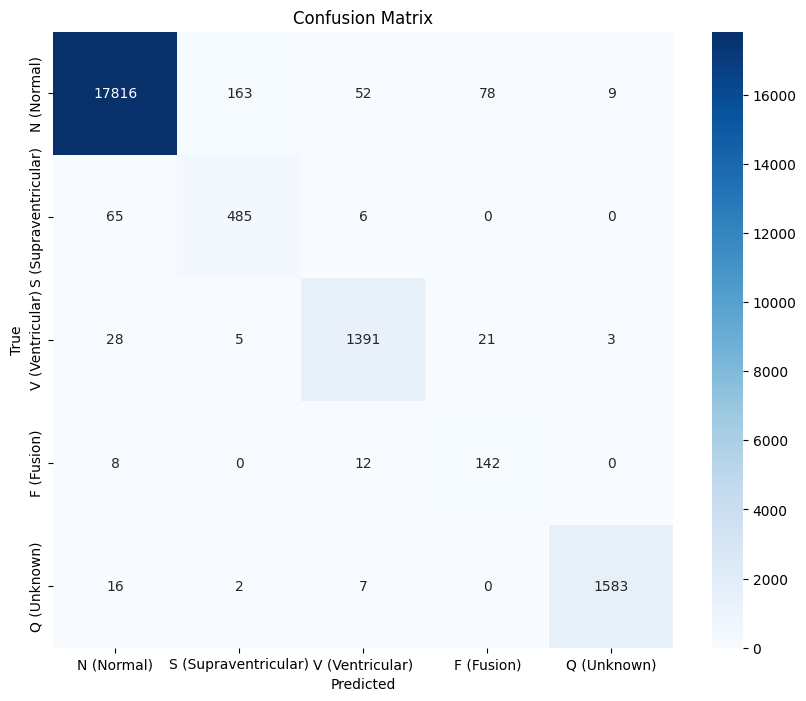

In [9]:
#Report
print("\nLoading Best Model for Final Evaluation...")
model.load_state_dict(torch.load(save_path))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels, lengths in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs, lengths)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = ['N (Normal)', 'S (Supraventricular)', 'V (Ventricular)', 'F (Fusion)', 'Q (Unknown)']

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

print("\nConfusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [12]:
import os
from IPython.display import FileLink

model_path = 'best_ecg_model.pth'

if os.path.exists(model_path):
    print(f"File found: {model_path}")
    display(FileLink(model_path))
else:
    print(f"Error: File '{model_path}' not found. Make sure the training finished and saved the model.")


File found: best_ecg_model.pth
Click the link below to download:


/kaggle/working/best_ecg_model.pth